/Users/setthakorntanom/miniconda3/envs/py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Sample: 100%|██████████| 1200/1200 [10:12,  1.96it/s, step size=1.73e-01, acc. prob=0.914]


Posterior mean of gamma: 0.6878280639648438
Posterior mean of c: 1.53009033203125


Fontconfig warning: ignoring UTF-8: not a valid region tag
Matplotlib is building the font cache; this may take a moment.


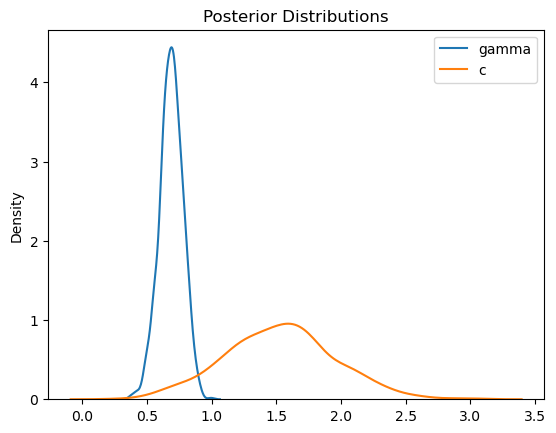

In [2]:
import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS
import torch

# Generate synthetic data
torch.manual_seed(42)
T = 50  # Number of time steps
true_gamma = 0.8
true_c = 1.0
s2 = 0.5  # Variance (s^2)

# Simulate hidden states (x_t) and observations (y_t)
x = torch.zeros(T)
y = torch.zeros(T)
x[0] = dist.Normal(0, s2**0.5).sample()
for t in range(1, T):
    x[t] = dist.Normal(true_gamma * x[t-1] + true_c, s2**0.5).sample()
    y[t] = dist.Normal(x[t], s2**0.5).sample()

# Define the probabilistic model
def model(y_obs):
    # Priors for gamma and c
    gamma = pyro.sample("gamma", dist.Normal(0, 1))  # Prior for gamma
    c = pyro.sample("c", dist.Normal(0, 1))          # Prior for c
    
    # Hidden state prior and likelihood
    x_prev = pyro.sample("x_0", dist.Normal(0, s2**0.5))  # Initial hidden state
    for t in range(1, len(y_obs)):
        x_t = pyro.sample(f"x_{t}", dist.Normal(gamma * x_prev + c, s2**0.5))
        pyro.sample(f"y_{t}", dist.Normal(x_t, s2**0.5), obs=y_obs[t])
        x_prev = x_t

# Perform MCMC with NUTS
nuts_kernel = NUTS(model)
mcmc = MCMC(nuts_kernel, num_samples=1000, warmup_steps=200, num_chains=1)
mcmc.run(y)
posterior_samples = mcmc.get_samples()

# Analyze posterior samples
print("Posterior mean of gamma:", posterior_samples["gamma"].mean().item())
print("Posterior mean of c:", posterior_samples["c"].mean().item())

# Visualize posterior distributions
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(posterior_samples["gamma"].numpy(), label="gamma")
sns.kdeplot(posterior_samples["c"].numpy(), label="c")
plt.legend()
plt.title("Posterior Distributions")
plt.show()


In [ ]:
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam
import matplotlib.pyplot as plt

# Check if CUDA is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on device: {device}")

# Simulate Data
def generate_data(T=100, gamma=0.8, c=1.0, s=0.5):
    """Generate synthetic data for testing."""
    x = torch.zeros(T, device=device)
    y = torch.zeros(T, device=device)
    x[0] = torch.randn(1, device=device) * s  # Initial state
    for t in range(1, T):
        x[t] = gamma * x[t-1] + c + torch.randn(1, device=device) * s
    y = x + torch.randn(T, device=device) * s
    return x, y

# Generate data
T = 100
true_gamma = 0.8
true_c = 1.0
true_s = 0.5
x_data, y_data = generate_data(T, gamma=true_gamma, c=true_c, s=true_s)

# Model Definition
def model(y_obs):
    # Priors for parameters
    gamma = pyro.sample("gamma", dist.Normal(0, 1))  # Prior for gamma
    c = pyro.sample("c", dist.Normal(0, 1))          # Prior for c
    s = true_s                                       # Assume known noise for simplicity

    # Initial latent state
    x_prev = pyro.sample("x_0", dist.Normal(0, 1))  # Initial x_0 ~ N(0, 1)

    # Sequentially sample latent states and observations
    for t in range(1, len(y_obs)):
        x_t = pyro.sample(f"x_{t}", dist.Normal(gamma * x_prev + c, s))
        pyro.sample(f"y_{t}", dist.Normal(x_t, s), obs=y_obs[t])
        x_prev = x_t

# Guide Definition (Variational Approximation)
def guide(y_obs):
    # Learnable parameters for gamma and c
    gamma_loc = pyro.param("gamma_loc", torch.tensor(0.0, device=device))
    gamma_scale = pyro.param("gamma_scale", torch.tensor(1.0, device=device), constraint=dist.constraints.positive)
    c_loc = pyro.param("c_loc", torch.tensor(0.0, device=device))
    c_scale = pyro.param("c_scale", torch.tensor(1.0, device=device), constraint=dist.constraints.positive)

    # Variational distributions for gamma and c
    pyro.sample("gamma", dist.Normal(gamma_loc, gamma_scale))
    pyro.sample("c", dist.Normal(c_loc, c_scale))

    # Variational distributions for latent states x_t
    x_prev_loc = pyro.param("x_0_loc", torch.tensor(0.0, device=device))
    x_prev_scale = pyro.param("x_0_scale", torch.tensor(1.0, device=device), constraint=dist.constraints.positive)
    pyro.sample("x_0", dist.Normal(x_prev_loc, x_prev_scale))

    for t in range(1, len(y_obs)):
        x_loc = pyro.param(f"x_{t}_loc", torch.tensor(0.0, device=device))
        x_scale = pyro.param(f"x_{t}_scale", torch.tensor(1.0, device=device), constraint=dist.constraints.positive)
        pyro.sample(f"x_{t}", dist.Normal(x_loc, x_scale))

# Optimizer and Inference
optimizer = Adam({"lr": 0.01})
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

# Training Loop
n_steps = 5000
losses = []
for step in range(n_steps):
    loss = svi.step(y_data)  # Ensure y_data is on CUDA
    losses.append(loss)
    if step % 500 == 0:
        print(f"Step {step} - Loss: {loss:.2f}")

# Results
print("Learned parameters:")
print(f"gamma: {pyro.param('gamma_loc').item()} ± {pyro.param('gamma_scale').item()}")
print(f"c: {pyro.param('c_loc').item()} ± {pyro.param('c_scale').item()}")
for t in range(T):
    if t == 0:
        print(f"x_0: {pyro.param('x_0_loc').item()} ± {pyro.param('x_0_scale').item()}")
    else:
        print(f"x_{t}: {pyro.param(f'x_{t}_loc').item()} ± {pyro.param(f'x_{t}_scale').item()}")

# Plot loss
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('SVI Loss Curve')
plt.show()


/opt/anaconda3/envs/nlp-class/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Running on device: cpu
Step 0 - Loss: 5917.91


KeyboardInterrupt: 